In [151]:
import pandas as pd
import numpy as np
import pandas.plotting as plot

In [6]:
df = pd.read_csv(r'/Users/mukundanramesh/projects/ai_ml_course_bootcamp_practice/ai-ml-course-bootcamp/Pandas/datasets/global_ev_adoption_behavior_2026.csv')
df.head()

,age,annual_income,education_level,city_type,daily_commute_km,weekly_travel_distance_km,current_vehicle_type,vehicle_age_years,fuel_expense_per_month,charging_station_accessibility,...,environmental_awareness_score,government_incentive_awareness,technology_affinity_score,range_anxiety_score,battery_replacement_concern,ev_knowledge_score,previous_ev_experience,ev_adoption_likelihood,monthly_energy_consumption_kwh,monthly_charging_cost
0,56,23019.0,High School,Suburban,39.8,205.7,Hatchback,6.1,317.1,3.9,...,8.3,6.4,5.2,4.6,3.5,6.9,0,High,199.8,28.5
1,46,26440.0,High School,Suburban,34.6,218.4,Sedan,4.4,290.0,4.5,...,7.8,10.0,5.7,5.5,7.4,6.9,1,High,139.8,22.9
2,46,57167.0,PhD,Suburban,30.5,177.7,Sedan,0.4,201.4,6.3,...,7.6,6.4,7.8,5.3,6.2,6.8,0,High,158.0,38.5
3,23,15841.0,Master,Suburban,44.6,325.9,SUV,0.0,407.3,5.2,...,6.2,5.6,5.1,7.9,5.7,7.2,0,Low,207.0,45.0
4,50,51571.0,Master,Urban,52.4,281.0,SUV,5.2,458.4,4.3,...,9.7,9.9,8.2,2.6,4.7,8.1,0,High,195.6,43.9


In [7]:
#Load the CSV and print its shape (rows/columns) and column names.
print(f"The shape of the data set is {df.shape}")
print(f"The columns available in the data set are \n {df.columns}")

The shape of the data set is (50000, 23)
The columns available in the data set are 
 Index(['age', 'annual_income', 'education_level', 'city_type',
       'daily_commute_km', 'weekly_travel_distance_km', 'current_vehicle_type',
       'vehicle_age_years', 'fuel_expense_per_month',
       'charging_station_accessibility', 'nearest_charging_station_km',
       'home_charging_available', 'electricity_cost_per_kwh',
       'environmental_awareness_score', 'government_incentive_awareness',
       'technology_affinity_score', 'range_anxiety_score',
       'battery_replacement_concern', 'ev_knowledge_score',
       'previous_ev_experience', 'ev_adoption_likelihood',
       'monthly_energy_consumption_kwh', 'monthly_charging_cost'],
      dtype='object')


In [10]:
#Check data types of each column — which are numeric vs. categorical?
df.dtypes

age                                 int64
annual_income                     float64
education_level                    object
city_type                          object
daily_commute_km                  float64
weekly_travel_distance_km         float64
current_vehicle_type               object
vehicle_age_years                 float64
fuel_expense_per_month            float64
charging_station_accessibility    float64
nearest_charging_station_km       float64
home_charging_available             int64
electricity_cost_per_kwh          float64
environmental_awareness_score     float64
government_incentive_awareness    float64
technology_affinity_score         float64
range_anxiety_score               float64
battery_replacement_concern       float64
ev_knowledge_score                float64
previous_ev_experience              int64
ev_adoption_likelihood             object
monthly_energy_consumption_kwh    float64
monthly_charging_cost             float64
dtype: object

In [16]:
# Find missing values in each column. Which 3 columns have missing data, and how many rows are affected?
df.isna().sum().sort_values(ascending = False)[:3]

education_level                   500
ev_knowledge_score                500
charging_station_accessibility    500
dtype: int64

In [19]:
#4. What is the average age, annual income, and daily commute distance of people in this dataset?
columns = ['age','annual_income','daily_commute_km']
df[columns].mean()

age                    44.996080
annual_income       44311.869380
daily_commute_km       35.169358
dtype: float64

In [57]:
#5. What is the minimum, maximum, and median monthly_charging_cost?
monthly_charging_cost = df.monthly_charging_cost
print(f"The minimum chargin cost is {monthly_charging_cost.min()}, the maximum charging cost is {monthly_charging_cost.max()} and the median charging cost is {monthly_charging_cost.median()}")

The minimum chargin cost is 1.4, the maximum charging cost is 199.6 and the median charging cost is 35.2


In [28]:
#6. What percentage of people already have home_charging_available?
pct_home_charging_available = ((df.home_charging_available == True).sum() / len(df)) *100
print(f"{pct_home_charging_available:.2f}% of people have home_charging_available")

64.98% of people have home_charging_available


In [29]:
#7. What percentage of people have previous_ev_experience?
pct_previous_ev_experience = ((df.previous_ev_experience == True).sum() / len(df)) *100 # or df.home_charging_available.mean() * 100
print(f"{pct_previous_ev_experience:.2f}% of people have previous_ev_experience")

19.82% of people have previous_ev_experience


In [59]:
#8. How many people fall into each ev_adoption_likelihood category (High/Medium/Low)? Show as counts and percentages.
df.groupby('ev_adoption_likelihood')['ev_adoption_likelihood'].count() # or df.ev_adoption_likelihood.value_counts()
df.ev_adoption_likelihood.value_counts(normalize=True) * 100

ev_adoption_likelihood
High      59.340
Medium    24.156
Low       16.504
Name: proportion, dtype: float64

In [69]:
#9. What is the distribution of city_type (Urban/Suburban/Rural)? Which is most common?
most_commom = df.groupby('city_type')['city_type'].count().sort_values(ascending=False)
print(most_commom)
print(f"The most common city type is {most_commom.idxmax()} with the distribution of {most_commom.max()}")


city_type
Urban       22645
Suburban    17348
Rural       10007
Name: city_type, dtype: int64
The most common city type is Urban with the distribution of 22645


In [41]:
#10. What is the distribution of current_vehicle_type (Hatchback/Sedan/SUV/Truck)?
df.groupby('current_vehicle_type')['current_vehicle_type'].count()

current_vehicle_type
Hatchback    12561
SUV          14933
Sedan        17512
Truck         4994
Name: current_vehicle_type, dtype: int64

In [46]:
#11 . How many people have each education_level?
df.groupby('education_level')['education_level'].count()

education_level
Bachelor       22350
High School    12401
Master         12244
PhD             2505
Name: education_level, dtype: int64

In [48]:
#12. What is the average annual_income for each ev_adoption_likelihood group (High vs Medium vs Low)?
df.groupby('ev_adoption_likelihood')['annual_income'].mean()

ev_adoption_likelihood
High      52219.834007
Low       29402.017693
Medium    35072.490810
Name: annual_income, dtype: float64

In [70]:
# 13. Does city_type affect average ev_adoption_likelihood-by-income? (i.e., group by city_type and compute average incom
print(df.groupby('city_type')['annual_income'].mean().sort_values(ascending=False))
print("Yes the city type affects the ev adoption rate")

city_type
Urban       44472.659086
Suburban    44266.227231
Rural       44027.140402
Name: annual_income, dtype: float64
Yes the city type affects the ev adoption rate


In [52]:
#14. Compare the average range_anxiety_score and environmental_awareness_score between people who have previous_ev_experience and those who don't.
df.groupby('previous_ev_experience')[['range_anxiety_score','environmental_awareness_score']].mean()

,range_anxiety_score,environmental_awareness_score
previous_ev_experience,,
0,5.289611,6.836638
1,5.281715,6.812503


In [73]:
#15. Is there a difference in nearest_charging_station_km between Urban, Suburban, and Rural areas?
nearst_station = df.groupby('city_type')['nearest_charging_station_km'].mean().sort_values(ascending=False)
print(nearst_station)
print(f"Yes the average value of nearest charging station in {nearst_station.idxmax()} is moore compared to others")

city_type
Suburban    10.032056
Rural        9.988078
Urban        3.649004
Name: nearest_charging_station_km, dtype: float64
Yes the average value of nearest charging station in Suburban is moore compared to others


In [180]:
#How many rows have annual_income greater than ₹50,000?
annual_income_greater = (df.annual_income > 50000).sum()
print(f"The count of rows with annual income greateer than ₹50K is {annual_income_greater}")

The count of rows with annual income greateer than ₹50K is 15953


In [181]:
#How many people are from Urban areas and have ev_adoption_likelihood == "High"?
result = len(df[(df.city_type =='Urban') & (df.ev_adoption_likelihood == 'High')].value_counts())
print(f"The count of people in Urban areas with High eve adoption likelihood is {result}")

The count of people in Urban areas with High eve adoption likelihood is 14261


In [214]:
#Show the 5 rows with the highest fuel_expense_per_month.
highest_fuel_expense_per_month = df.sort_values(by='fuel_expense_per_month',ascending=False)
highest_fuel_expense_per_month.iloc[:5]

,age,annual_income,education_level,city_type,daily_commute_km,weekly_travel_distance_km,current_vehicle_type,vehicle_age_years,fuel_expense_per_month,charging_station_accessibility,...,technology_affinity_score,range_anxiety_score,battery_replacement_concern,ev_knowledge_score,previous_ev_experience,ev_adoption_likelihood,monthly_energy_consumption_kwh,monthly_charging_cost,income_per_age,is_high_income
37026,33,84824.0,High School,Urban,97.9,501.7,Hatchback,0.0,862.0,6.6,...,8.6,2.8,3.9,8.7,1,High,389.9,102.4,2570.424242,True
13538,24,9912.0,Master,Urban,89.0,504.3,Truck,1.2,797.4,7.9,...,4.8,8.9,5.7,3.7,0,Low,380.2,109.9,413.000000,False
20643,64,31172.0,High School,Urban,90.8,692.4,SUV,5.0,794.0,9.0,...,3.7,7.7,6.7,3.7,0,Low,495.0,169.2,487.062500,False
8463,33,15945.0,Bachelor,Urban,89.4,646.6,SUV,5.8,792.3,7.9,...,6.2,8.7,5.7,7.0,0,Medium,524.0,130.6,483.181818,False
36278,43,60830.0,High School,Rural,80.7,561.0,SUV,5.8,780.0,4.2,...,7.6,5.6,8.5,8.2,1,High,418.9,123.0,1414.651163,True


In [90]:
#Show the 5 rows with the lowest nearest_charging_station_km.
lowest_nearest_charging_station_km = df.sort_values(by='nearest_charging_station_km',ascending=True)
lowest_nearest_charging_station_km.iloc[:5]

,age,annual_income,education_level,city_type,daily_commute_km,weekly_travel_distance_km,current_vehicle_type,vehicle_age_years,fuel_expense_per_month,charging_station_accessibility,...,environmental_awareness_score,government_incentive_awareness,technology_affinity_score,range_anxiety_score,battery_replacement_concern,ev_knowledge_score,previous_ev_experience,ev_adoption_likelihood,monthly_energy_consumption_kwh,monthly_charging_cost
9922,49,47339.0,Bachelor,Urban,34.2,184.5,Hatchback,1.7,301.8,6.6,...,10.0,5.8,7.5,4.2,3.1,8.7,0,High,164.8,44.5
46235,50,36314.0,Master,Urban,5.0,38.4,Sedan,4.3,16.8,4.5,...,5.8,6.3,2.5,8.4,3.6,3.9,0,Medium,36.3,7.4
11872,63,65489.0,High School,Urban,48.7,263.9,Hatchback,4.0,383.4,5.2,...,7.3,4.5,7.6,3.0,5.4,7.3,0,High,195.1,61.9
36676,59,26263.0,Master,Urban,48.0,273.3,Truck,3.6,326.1,5.7,...,7.3,4.8,4.5,7.8,3.1,4.6,0,Medium,262.5,79.7
24780,33,42330.0,PhD,Urban,37.2,221.0,Hatchback,6.0,292.8,8.0,...,8.9,3.0,7.8,5.2,4.8,8.0,0,High,215.3,47.6


In [99]:
#Filter the dataset to rows where daily_commute_km > 50. How many such rows are there, and what's their average ev_knowledge_score?
daily_commute_km_greater_50 = df[df.daily_commute_km > 50]
print(f"There are {len(daily_commute_km_greater_50)} rows whose daily commute is greater than 50 kms")
print(f"The average EV knowledge score of people with daily commute is greater than 50 kms is {daily_commute_km_greater_50.ev_knowledge_score.mean():.2f}")

There are 7907 rows whose daily commute is greater than 50 kms
The average EV knowledge score of people with daily commute is greater than 50 kms is 6.76


In [182]:
# What is the most common combination of city_type and current_vehicle_type? (Hint: groupby on both columns together.)
df.groupby(['city_type','current_vehicle_type']).size().idxmax()

('Urban', 'Sedan')

In [112]:
# Build a cross-tab (pd.crosstab) between city_type and ev_adoption_likelihood. Which city type has the highest count of "High" adoption likelihood?
crosstab = pd.crosstab(df.city_type,df.ev_adoption_likelihood)
city_with_high = crosstab.sort_values(by="High",ascending=False)
print(city_with_high)
print("The city type Urban has the higest count of High")

ev_adoption_likelihood   High   Low  Medium
city_type                                  
Urban                   14723  2864    5058
Suburban                 9462  3417    4469
Rural                    5485  1971    2551


In [121]:
#How many people have both home_charging_available == 1 and previous_ev_experience == 1?
count_home_charging_available_and_previous_ev_experience = df[(df.home_charging_available == 1) & (df.previous_ev_experience == 1)]
print(f"The count of people who have both home_charging_available and previous_ev_experience is {len(count_home_charging_available_and_previous_ev_experience)}")

The count of people who have both home_charging_available and previous_ev_experience is 6555


In [189]:
# What percentage of people with education_level == "PhD" have ev_adoption_likelihood == "High"?
phd_total = (df.education_level == 'PhD').sum()
phd_high = ((df.education_level=='PhD') & (df.ev_adoption_likelihood=='High')).sum()
print(f"{(phd_high / phd_total) * 100}% of pople wiht PhD have High ev_adoption_likelihood")

59.12175648702595% of pople wiht PhD have High ev_adoption_likelihood


In [144]:
#10. Compute the correlation matrix of all numeric columns (df.corr()). Which two columns have the strongest positive correlation (excluding a column correlating with itself)?
corr = df.corr(numeric_only=True)
corr

,age,annual_income,daily_commute_km,weekly_travel_distance_km,vehicle_age_years,fuel_expense_per_month,charging_station_accessibility,nearest_charging_station_km,home_charging_available,electricity_cost_per_kwh,environmental_awareness_score,government_incentive_awareness,technology_affinity_score,range_anxiety_score,battery_replacement_concern,ev_knowledge_score,previous_ev_experience,monthly_energy_consumption_kwh,monthly_charging_cost
age,1.000000,-0.004244,-0.005042,-0.004831,-0.001774,-0.004150,-0.005380,-0.000833,0.000179,-0.000437,-0.005495,0.002033,-0.000675,0.001458,-0.000389,-0.005003,-0.000335,-0.003461,-0.002225
annual_income,-0.004244,1.000000,0.000434,-0.000126,0.001579,-0.000225,0.000077,-0.003564,-0.003209,0.004607,0.316546,0.003436,0.448863,-0.369841,0.001748,0.382863,-0.006043,0.002640,0.003613
daily_commute_km,-0.005042,0.000434,1.000000,0.944852,-0.006027,0.951539,-0.003056,0.000991,0.008939,0.000073,0.004628,-0.000623,0.005281,0.000566,-0.003723,0.000477,0.001189,0.884948,0.676037
weekly_travel_distance_km,-0.004831,-0.000126,0.944852,1.000000,-0.003314,0.898885,-0.001344,0.000564,0.008867,0.001769,0.005971,-0.000640,0.005322,-0.000685,-0.000820,0.001102,-0.001768,0.936115,0.715476
vehicle_age_years,-0.001774,0.001579,-0.006027,-0.003314,1.000000,-0.008997,-0.011031,0.006891,-0.000083,0.007535,-0.006825,-0.000440,-0.003061,-0.001909,-0.006717,-0.004620,-0.000001,-0.003190,-0.000322
fuel_expense_per_month,-0.004150,-0.000225,0.951539,0.898885,-0.008997,1.000000,-0.003575,-0.002154,0.007795,0.001788,0.003766,0.002103,0.003635,0.002218,-0.004115,-0.000048,0.002505,0.842182,0.644071
charging_station_accessibility,-0.005380,0.000077,-0.003056,-0.001344,-0.011031,-0.003575,1.000000,-0.293203,-0.001493,-0.005064,0.004147,-0.003768,0.003774,-0.000558,0.001203,0.006731,-0.005144,-0.000136,-0.002397
nearest_charging_station_km,-0.000833,-0.003564,0.000991,0.000564,0.006891,-0.002154,-0.293203,1.000000,-0.001072,0.002761,-0.003333,-0.003325,-0.001339,0.002467,-0.004109,-0.003539,-0.009308,0.000629,0.000983
home_charging_available,0.000179,-0.003209,0.008939,0.008867,-0.000083,0.007795,-0.001493,-0.001072,1.000000,0.008744,-0.006349,0.001630,-0.003705,0.006191,-0.000234,-0.007812,0.012187,0.007036,0.010099
electricity_cost_per_kwh,-0.000437,0.004607,0.000073,0.001769,0.007535,0.001788,-0.005064,0.002761,0.008744,1.000000,-0.002969,0.006316,0.005301,-0.001965,0.010848,0.005227,0.003606,0.003133,0.583916


In [143]:
print("Monthly Charging cost is positively corellaed to weekly_travel_distance_km")

Monthly Charging cost is positively corellaed to weekly_travel_distance_km


In [148]:
#11. What is the correlation between annual_income and monthly_charging_cost?
print(f"The correlation value between annual income and monthly chargin cost is {corr.loc['annual_income','monthly_charging_cost']}")

The correlation value between annual income and monthly chargin cost is 0.0036131077582082327


In [149]:
#12. For each ev_adoption_likelihood group, compute the mean, median, and max of annual_income — all in a single .agg() call.
df.groupby('ev_adoption_likelihood')['annual_income'].agg(['mean','median','max'])

,mean,median,max
ev_adoption_likelihood,,,
High,52219.834007,46653.5,250000.0
Low,29402.017693,26403.5,188434.0
Medium,35072.490810,30047.0,231595.0


In [150]:
#13. What is the average annual_income when grouping by both city_type and ev_adoption_likelihood together?
df.groupby(['city_type','ev_adoption_likelihood'])['annual_income'].mean()

city_type  ev_adoption_likelihood
Rural      High                      52560.881860
           Low                       29806.135464
           Medium                    36666.116817
Suburban   High                      53150.822870
           Low                       29314.990928
           Medium                    36887.021705
Urban      High                      51494.461183
           Low                       29227.734986
           Medium                    32665.516014
Name: annual_income, dtype: float64

<Axes: title={'center': 'EV Adoption Likelihood'}, xlabel='ev_adoption_likelihood'>

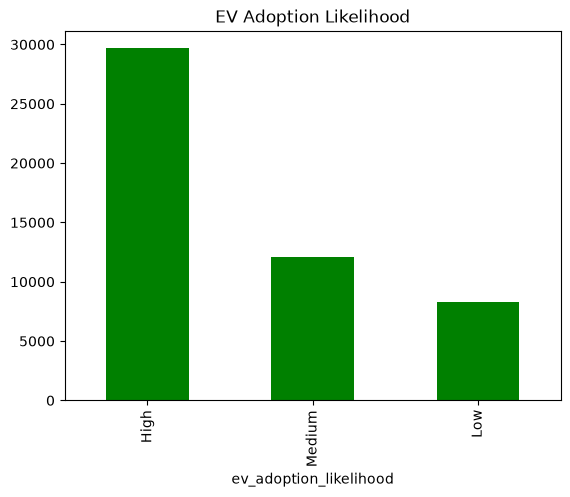

In [154]:
#14. Plot a bar chart of the value counts for ev_adoption_likelihood.
ev_adoption_likelihood_count = df.ev_adoption_likelihood.value_counts()
ev_adoption_likelihood_count.plot.bar(title="EV Adoption Likelihood",color = 'green')

<Axes: title={'center': 'Age'}, ylabel='Frequency'>

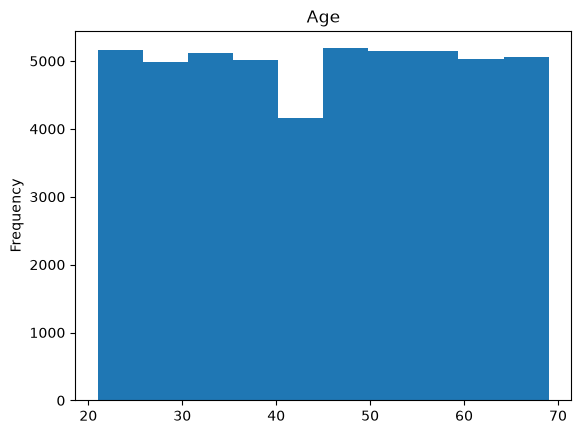

In [155]:
#Plot a histogram of the age column (try 10 bins).
df.age.plot.hist(title="Age",bins=10)

<Axes: >

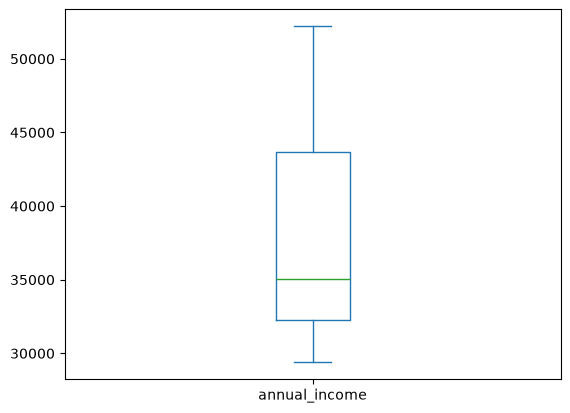

In [190]:
#16. Plot a boxplot of annual_income grouped by ev_adoption_likelihood.
annual_income_by_ev_adoption_likelihood = df.groupby("ev_adoption_likelihood")["annual_income"].mean()
annual_income_by_ev_adoption_likelihood.plot.box()

In [158]:
#17. Create a new column income_per_age = annual_income / age. Show the top 5 rows sorted by this new column.
df["income_per_age"] = df.annual_income / df.age
df.income_per_age.head()

0     411.053571
1     574.782609
2    1242.760870
3     688.739130
4    1031.420000
Name: income_per_age, dtype: float64

In [168]:
#18. Create a new boolean column is_high_income that's True when annual_income is above the overall median income. What percentage of rows are True?
df["is_high_income"]=df.annual_income > df.annual_income.median()
pct_is_high_income = (df.is_high_income.sum()/ len(df)) * 100
print(f"{pct_is_high_income}% rows are is_high_income")

49.998% rows are is_high_income


In [169]:
#19. What is the maximum value of vehicle_age_years? How many rows have vehicle_age_years > 15?
max_vehicle_age_years = df.vehicle_age_years.max()
pct_age_greater_15  = ((df.vehicle_age_years > 15).sum() / len(df)) * 100
print(f"The maximum value in the vehicle age column is {max_vehicle_age_years} and the {pct_age_greater_15:.2f}% are greater than 15 years")

The maximum value in the vehicle age column is 20.0 and the 0.12% are greater than 15 years


In [178]:
#20. Run df.describe() on the whole dataframe. What is the standard deviation of annual_income, and what does that tell you about how spread out incomes are?
desc = df.describe()
print(f"The  STD of annual income is {desc.loc['std','annual_income']}")

The  STD of annual income is 26109.170784476086


In [174]:
desc

,age,annual_income,daily_commute_km,weekly_travel_distance_km,vehicle_age_years,fuel_expense_per_month,charging_station_accessibility,nearest_charging_station_km,home_charging_available,electricity_cost_per_kwh,environmental_awareness_score,government_incentive_awareness,technology_affinity_score,range_anxiety_score,battery_replacement_concern,ev_knowledge_score,previous_ev_experience,monthly_energy_consumption_kwh,monthly_charging_cost,income_per_age
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,49500.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,49500.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,44.996080,44311.869380,35.169358,228.727200,6.012842,295.169608,5.892947,7.132370,0.64976,0.215359,6.831854,5.979970,6.721914,5.288046,4.998338,6.755673,0.198200,186.740260,40.235028,1105.350883
std,14.110844,26109.170784,14.736042,101.147254,2.947132,130.178552,2.152186,4.801992,0.47705,0.077914,1.920217,1.955106,1.990730,2.059862,1.955411,1.945842,0.398648,88.245302,24.940343,806.935819
min,21.000000,5104.000000,5.000000,25.000000,0.000000,-99.700000,1.000000,0.500000,0.00000,0.080000,2.000000,1.000000,2.000000,2.000000,1.000000,1.000000,0.000000,15.600000,1.400000,82.322581
25%,33.000000,25617.750000,25.000000,157.700000,3.900000,205.200000,4.400000,3.000000,0.00000,0.150000,5.400000,4.600000,5.200000,3.700000,3.600000,5.300000,0.000000,124.500000,21.600000,564.679884
50%,45.000000,37891.000000,35.100000,224.100000,6.000000,294.800000,5.900000,6.900000,1.00000,0.220000,7.000000,6.000000,6.700000,5.000000,5.000000,7.000000,0.000000,179.300000,35.200000,885.597619
75%,57.000000,56051.250000,45.200000,294.500000,8.000000,383.000000,7.400000,10.700000,1.00000,0.280000,8.400000,7.300000,8.500000,6.800000,6.300000,8.300000,0.000000,241.500000,54.100000,1397.024510
max,69.000000,250000.000000,97.900000,732.300000,20.000000,862.000000,10.000000,28.500000,1.00000,0.350000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,1.000000,645.900000,199.600000,10844.952381


In [193]:
#How many rows have a missing value in any column? (.isna().any(axis=1))
print(f"The data set has {df.isna().any(axis=1).sum()} values")

The data set has 1489 values


In [199]:
#Drop all rows with at least one missing value into a new dataframe df_clean. How many rows remain?
df_clean = df.dropna(axis=0)
print(f"{df_clean.size} rows remain after cleaning")

1212775 rows remain after cleaning


In [206]:
# Instead of dropping, fill missing values in education_level with "Unknown". Confirm the column has zero missing values afterward.
df.education_level = df.education_level.fillna(value="Unknown")
df.education_level.isna().sum()

np.int64(0)

In [212]:
#4. Use .nlargest(5, 'fuel_expense_per_month') to get the top 5 rows. Compare to your earlier sort_values().head() — same rows?
df.nlargest(5,"fuel_expense_per_month")

,age,annual_income,education_level,city_type,daily_commute_km,weekly_travel_distance_km,current_vehicle_type,vehicle_age_years,fuel_expense_per_month,charging_station_accessibility,...,technology_affinity_score,range_anxiety_score,battery_replacement_concern,ev_knowledge_score,previous_ev_experience,ev_adoption_likelihood,monthly_energy_consumption_kwh,monthly_charging_cost,income_per_age,is_high_income
37026,33,84824.0,High School,Urban,97.9,501.7,Hatchback,0.0,862.0,6.6,...,8.6,2.8,3.9,8.7,1,High,389.9,102.4,2570.424242,True
13538,24,9912.0,Master,Urban,89.0,504.3,Truck,1.2,797.4,7.9,...,4.8,8.9,5.7,3.7,0,Low,380.2,109.9,413.000000,False
20643,64,31172.0,High School,Urban,90.8,692.4,SUV,5.0,794.0,9.0,...,3.7,7.7,6.7,3.7,0,Low,495.0,169.2,487.062500,False
8463,33,15945.0,Bachelor,Urban,89.4,646.6,SUV,5.8,792.3,7.9,...,6.2,8.7,5.7,7.0,0,Medium,524.0,130.6,483.181818,False
36278,43,60830.0,High School,Rural,80.7,561.0,SUV,5.8,780.0,4.2,...,7.6,5.6,8.5,8.2,1,High,418.9,123.0,1414.651163,True


In [217]:
highest_fuel_expense_per_month.iloc[:5] == df.nlargest(5,"fuel_expense_per_month")

,age,annual_income,education_level,city_type,daily_commute_km,weekly_travel_distance_km,current_vehicle_type,vehicle_age_years,fuel_expense_per_month,charging_station_accessibility,...,technology_affinity_score,range_anxiety_score,battery_replacement_concern,ev_knowledge_score,previous_ev_experience,ev_adoption_likelihood,monthly_energy_consumption_kwh,monthly_charging_cost,income_per_age,is_high_income
37026,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
13538,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
20643,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
8463,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
36278,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [218]:
#5. Use .nsmallest(5, 'monthly_charging_cost') to get the 5 lowest-cost rows.
df.nsmallest(5,'monthly_charging_cost')

,age,annual_income,education_level,city_type,daily_commute_km,weekly_travel_distance_km,current_vehicle_type,vehicle_age_years,fuel_expense_per_month,charging_station_accessibility,...,technology_affinity_score,range_anxiety_score,battery_replacement_concern,ev_knowledge_score,previous_ev_experience,ev_adoption_likelihood,monthly_energy_consumption_kwh,monthly_charging_cost,income_per_age,is_high_income
3725,58,63108.0,PhD,Rural,5.0,25.9,Sedan,9.1,55.3,4.4,...,7.5,3.5,2.7,8.8,0,High,15.8,1.4,1088.068966,True
4172,42,34289.0,Master,Rural,5.0,26.5,Hatchback,2.3,48.1,8.6,...,5.3,3.8,4.5,5.9,0,High,17.1,1.5,816.404762,False
16438,23,54592.0,High School,Rural,5.0,25.8,SUV,8.1,64.5,6.9,...,8.4,3.2,1.7,7.7,1,High,18.6,1.5,2373.565217,True
4853,60,49162.0,Bachelor,Urban,5.0,25.3,Truck,8.4,69.6,8.9,...,5.6,2.7,10.0,8.6,0,High,18.7,1.6,819.366667,True
21607,49,80120.0,Master,Urban,5.0,29.7,Truck,2.6,-15.5,7.5,...,9.6,4.4,2.9,8.7,1,High,18.8,1.6,1635.102041,True


In [231]:
#6. What % of the dataset is "Urban"? Use value_counts(normalize=True) * 100.
(df[df.city_type == "Urban"].value_counts(normalize=True) / len(df[df.city_type == "Urban"])) * 100

age  annual_income  education_level  city_type  daily_commute_km  weekly_travel_distance_km  current_vehicle_type  vehicle_age_years  fuel_expense_per_month  charging_station_accessibility  nearest_charging_station_km  home_charging_available  electricity_cost_per_kwh  environmental_awareness_score  government_incentive_awareness  technology_affinity_score  range_anxiety_score  battery_replacement_concern  ev_knowledge_score  previous_ev_experience  ev_adoption_likelihood  monthly_energy_consumption_kwh  monthly_charging_cost  income_per_age  is_high_income
21   8570.0         Bachelor         Urban      6.2               42.1                       Sedan                 2.3                90.3                    9.2                             0.5                          1                        0.31                      7.3                            2.5                             5.7                        6.9                  3.2                          5.3                 0     

In [228]:
(df.city_type == "Urban").value_counts(normalize = True) * 100

city_type
False    54.71
True     45.29
Name: proportion, dtype: float64

In [242]:
#7. What % of Rural people specifically have previous_ev_experience == 1? (denominator = Rural count only, not the whole dataset)
df[(df.city_type == "Rural") & (df.previous_ev_experience == 1)].value_counts().sum() / len(df[df.city_type == 'Rural']) *100

np.float64(19.266513440591588)

In [243]:
#8. What % of people with home_charging_available == 1 also have ev_adoption_likelihood == "High"? (denominator = home-charging owners only)
df[(df.ev_adoption_likelihood == "High") & (df.home_charging_available == 1)].value_counts().sum() / len(df[df.home_charging_available == 1]) *100

np.float64(61.17027825658705)

In [244]:
#9. Use .idxmax() to find the row index with the single highest annual_income. Print that full row.
max_row_annual_income = df.annual_income.idxmax()
df.loc[max_row_annual_income]

age                                        34
annual_income                        250000.0
education_level                   High School
city_type                               Urban
daily_commute_km                         37.7
weekly_travel_distance_km               225.5
current_vehicle_type                Hatchback
vehicle_age_years                         5.9
fuel_expense_per_month                  319.7
charging_station_accessibility            3.6
nearest_charging_station_km               3.6
home_charging_available                     1
electricity_cost_per_kwh                 0.18
environmental_awareness_score             5.1
government_incentive_awareness           10.0
technology_affinity_score                 9.9
range_anxiety_score                       2.7
battery_replacement_concern               3.5
ev_knowledge_score                        7.1
previous_ev_experience                      0
ev_adoption_likelihood                   High
monthly_energy_consumption_kwh    

In [247]:
#10. Use .idxmin() to find the row index with the lowest age.
min_row_age = df.age.idxmin()
df.loc[min_row_age]

age                                        21
annual_income                         40102.0
education_level                      Bachelor
city_type                            Suburban
daily_commute_km                         28.6
weekly_travel_distance_km               218.3
current_vehicle_type                      SUV
vehicle_age_years                         7.9
fuel_expense_per_month                  295.1
charging_station_accessibility            3.1
nearest_charging_station_km              12.7
home_charging_available                     0
electricity_cost_per_kwh                 0.08
environmental_awareness_score             9.0
government_incentive_awareness            8.1
technology_affinity_score                 8.3
range_anxiety_score                       2.9
battery_replacement_concern               1.5
ev_knowledge_score                        7.5
previous_ev_experience                      1
ev_adoption_likelihood                   High
monthly_energy_consumption_kwh    

In [249]:
#11. Rename the column ev_knowledge_score to knowledge_score (just for practice). Print the updated column list.
df.rename(columns={"ev_knowledge_score":"knowledge_score"},inplace=True)
df.columns

Index(['age', 'annual_income', 'education_level', 'city_type',
       'daily_commute_km', 'weekly_travel_distance_km', 'current_vehicle_type',
       'vehicle_age_years', 'fuel_expense_per_month',
       'charging_station_accessibility', 'nearest_charging_station_km',
       'home_charging_available', 'electricity_cost_per_kwh',
       'environmental_awareness_score', 'government_incentive_awareness',
       'technology_affinity_score', 'range_anxiety_score',
       'battery_replacement_concern', 'knowledge_score',
       'previous_ev_experience', 'ev_adoption_likelihood',
       'monthly_energy_consumption_kwh', 'monthly_charging_cost',
       'income_per_age', 'is_high_income'],
      dtype='object')

In [254]:
#12. Use pivot_table (instead of groupby) to get average annual_income for each city_type × ev_adoption_likelihood combo. Does it match your earlier groupby answer?
print(df.pivot_table.__doc__)
df.pivot_table(columns=["city_type","ev_adoption_likelihood"])


Create a spreadsheet-style pivot table as a DataFrame.

The levels in the pivot table will be stored in MultiIndex objects
(hierarchical indexes) on the index and columns of the result DataFrame.

Parameters
----------
values : list-like or scalar, optional
    Column or columns to aggregate.
index : column, Grouper, array, or list of the previous
    Keys to group by on the pivot table index. If a list is passed,
    it can contain any of the other types (except list). If an array is
    passed, it must be the same length as the data and will be used in
    the same manner as column values.
columns : column, Grouper, array, or list of the previous
    Keys to group by on the pivot table column. If a list is passed,
    it can contain any of the other types (except list). If an array is
    passed, it must be the same length as the data and will be used in
    the same manner as column values.
aggfunc : function, list of functions, dict, default "mean"
    If a list of functions is pa

KeyError: 'ev_adoption_likelihood_count'

In [256]:
#How many people have monthly_charging_cost greater than ₹50?
df_monthly_charging_cost_greater_50 = df[df.monthly_charging_cost > 50]
len(df_monthly_charging_cost_greater_50)

14643

In [257]:
#How many people have vehicle_age_years less than 2 (a fairly new vehicle)?
len(df[df.vehicle_age_years <=2])

4758

In [259]:
#What percentage of the entire dataset has government_incentive_awareness greater than 8?
df_government_incentive_awareness = df[df.government_incentive_awareness > 8]
(len(df_government_incentive_awareness)/ len(df)) * 100

15.196000000000002

In [266]:
#4. How many people are both city_type == "Suburban" and ev_adoption_likelihood == "Medium"?
df_city_type_Suburban = df[df.city_type == 'Suburban']
df_ev_adoption_likelihood = df_city_type_Suburban.ev_adoption_likelihood == "Medium"
len(df_ev_adoption_likelihood)

17348

In [268]:
#5. What % of Suburban people specifically fall into "Medium" adoption likelihood? (denominator = Suburban only)
(df_ev_adoption_likelihood.sum() / len(df_city_type_Suburban)) * 100

np.float64(25.760894627622783)

In [271]:
#6. What % of people with previous_ev_experience == 1 also have home_charging_available == 1? (denominator = previous EV owners only)
df_previous_ev_experience = df[df.previous_ev_experience == 1]
df_home_charging_available = (df_previous_ev_experience.home_charging_available == 1).sum()
(df_home_charging_available / len(df_previous_ev_experience)) * 100

np.float64(66.14530776992936)

In [276]:
#7. Filter the dataset to city_type == "Rural". How many rows are in that filtered dataframe? Use the right attribute — not .size.
df[df.city_type == 'Rural'].shape[0]

10007

In [277]:
#8. Print both .size and .shape[0] on that Rural subset. What's the actual relationship between the two numbers?
df[df.city_type == 'Rural'].size,df[df.city_type == 'Rural'].shape[0]

(250175, 10007)

In [278]:
#D. Spot-the-bug (no new analysis — just find what's wrong)
#9. Does this correctly count Urban people with "Low" adoption likelihood? Why or why not?
result = df[(df.city_type == "Urban") & (df.ev_adoption_likelihood == "Low")].value_counts().sum()
result

np.int64(2808)

np.float64(100.0)